# Support Vector Machine (SVM) Classifier

## Intuition
Support Vector Machines are classifiers that try to **draw the best possible boundary** between different classes.  
Instead of just separating the data, SVM looks for the boundary that is **as far away as possible from the closest points of each class**.  
These closest points are called **support vectors**, and they are the most important data points because they define the boundary.

---

## How It Works
1. **Hyperplane (Decision Boundary)**
   - In 2D → it’s a line separating two classes.  
   - In 3D → it’s a plane.  
   - In higher dimensions → it’s called a hyperplane.  
   - The hyperplane is chosen so that it separates classes with the **maximum margin**.

2. **Support Vectors**
   - These are the data points closest to the boundary.  
   - They “support” the boundary because moving them would change the decision line.  
   - Only these critical points matter for defining the classifier.

3. **Margin Maximization**
   - SVM doesn’t just separate classes; it tries to maximize the gap (margin) between them.  
   - A larger margin means the classifier is more confident and less sensitive to noise.

---

## Handling Non‑Linear Data
- Real‑world data is often not linearly separable.  
- SVM uses the **kernel trick** to project data into a higher dimension where it becomes separable.  
- Common kernels:
  - **Linear Kernel** → straight line boundary.  
  - **Polynomial Kernel** → curved boundaries.  
  - **RBF (Radial Basis Function)** → flexible, circular boundaries.  
  - **Sigmoid Kernel** → behaves like a neural network.

---

## Soft Margin Concept
- Perfect separation is not always possible.  
- SVM allows some misclassifications but penalizes them.  
- This balance is controlled by a parameter called **C**:
  - High C → strict separation, less tolerance for errors.  
  - Low C → wider margin, more tolerance for errors.  

---

## Advantages
- Works well in high‑dimensional spaces.  
- Effective when features outnumber samples.  
- Robust to overfitting if parameters are tuned properly.  

---

## Limitations
- Training can be slow for very large datasets.  
- Choosing the right kernel and parameters is critical.  
- Less interpretable compared to decision trees.  

---

*SVM finds the boundary that maximizes the margin between classes, using kernels when data isn’t linearly separable.*


# Types of Kernels in SVM

| Kernel Type   | Boundary Shape   | Best For                     | Pros                          | Cons                        |
|---------------|------------------|------------------------------|-------------------------------|-----------------------------|
| **Linear**    | Straight line    | Linearly separable data      | Fast, simple                  | Poor for non‑linear data    |
| **Polynomial**| Curved (degree d)| Feature interactions         | Captures complex patterns     | Risk of overfitting         |
| **RBF**       | Flexible, circular | Non‑linear, clustered data | Very powerful, widely used    | Needs careful tuning        |
| **Sigmoid**   | Logistic‑like    | Neural network style problems| Probabilistic feel            | Less stable, rarely used    |

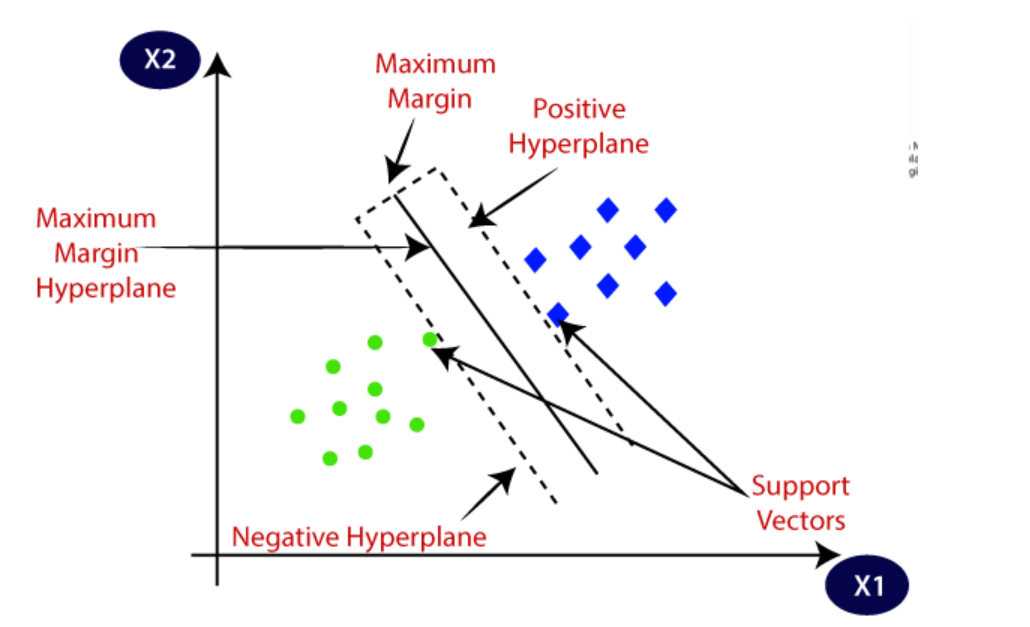

In [3]:
from IPython.display import Image, display

# Load and display the image directly
display(Image(filename='svm.png'))   # replace with your actual filename

# Understanding the SVM Diagram

## What the Diagram Shows

### Two Classes of Data Points
- **Green circles** → one class (Class 0).  
- **Blue diamonds** → another class (Class 1).  
- Plotted in a 2D feature space (X1 vs X2).

### Maximum Margin Hyperplane (Solid Line)
- The decision boundary chosen by SVM.  
- Separates the two classes.  
- Unlike other classifiers, SVM doesn’t just find *any* boundary, it finds the one that **maximizes the margin**.

### Positive & Negative Hyperplanes (Dashed Lines)
- Parallel to the main hyperplane.  
- Touch the closest data points from each class.  
- The region between them is the **margin**.

### Support Vectors (Points on the Margin)
- Critical data points lying exactly on the dashed lines.  
- They “support” the hyperplane because they define its position.  
- Removing other points doesn’t change the boundary, but removing support vectors **would shift it**.

---

## Intuition of How SVM Works

1. **Find a Boundary**  
   - Many boundaries could separate the classes.  
   - SVM asks: *Which boundary gives the widest possible gap between the two classes?*

2. **Maximize the Margin**  
   - The margin is the distance between the dashed lines.  
   - A wider margin means the classifier is more confident and less likely to misclassify new points.

3. **Focus on Critical Points**  
   - Only the support vectors matter for defining the boundary.  
   - Other points farther away don’t influence the decision line.

4. **Generalization**  
   - By maximizing the margin, SVM avoids overfitting.  
   - It’s less sensitive to noise because it doesn’t hug the data too tightly.

---

## Why This Matters

- **Robustness** → Even if new points are added, as long as they don’t cross the margin, the boundary remains stable.  
- **Efficiency** → Only a few points (support vectors) define the model, not the entire dataset.  
- **Flexibility** → With kernels, SVM can handle curved or complex boundaries when data isn’t linearly separable.  

---

*SVM is like drawing the widest possible road between two groups of houses, the houses closest to the road (support vectors) decide where the road lies.*

In [1]:
# NumPy is used for numerical computations and handling arrays
import numpy as np  

# Matplotlib is used for creating visualizations and plots
import matplotlib.pyplot as plt  

# Pandas is used for data manipulation and analysis with DataFrames
import pandas as pd  

In [2]:
# Load the dataset from a CSV file into a Pandas DataFrame
dataset = pd.read_csv('Social_Network_Ads.csv')

# Select all columns except the last one as features (X)
X = dataset.iloc[:, :-1].values

# Select the last column as the target variable (y)
y = dataset.iloc[:, -1].values


In [3]:
# Import the function to split datasets into training and test sets
from sklearn.model_selection import train_test_split

# Split the features (X) and target (y) into training and test sets
# test_size = 0.25 means 25% of the data will be used for testing
# random_state = 0 ensures reproducibility of the split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 0)


In [4]:
# Print the first 5 rows only
print(X_train[:5])

[[    44  39000]
 [    32 120000]
 [    38  50000]
 [    32 135000]
 [    52  21000]]


In [5]:
# Print the first 10 target values
print(y_train[:10])

# Check the shape of the target array
print("y_train shape:", y_train.shape)

# Count how many samples belong to each class
print("Class distribution:", pd.Series(y_train).value_counts())

[0 1 0 1 1 1 0 0 0 0]
y_train shape: (300,)
Class distribution: 0    189
1    111
Name: count, dtype: int64


In [6]:
# Import the StandardScaler class for feature scaling
from sklearn.preprocessing import StandardScaler

# Create a StandardScaler object
sc = StandardScaler()

# Fit the scaler on the training data and transform it
# This standardizes features by removing the mean and scaling to unit variance
X_train = sc.fit_transform(X_train)

# Apply the same transformation to the test data (without refitting)
X_test = sc.transform(X_test)

In [7]:
# Show the first 5 rows of scaled training data
print(X_train[:5])

# Verify the mean and standard deviation of each feature
print("Feature means:", X_train.mean(axis=0))
print("Feature stds:", X_train.std(axis=0))

[[ 0.58164944 -0.88670699]
 [-0.60673761  1.46173768]
 [-0.01254409 -0.5677824 ]
 [-0.60673761  1.89663484]
 [ 1.37390747 -1.40858358]]
Feature means: [1.45809291e-16 1.50990331e-16]
Feature stds: [1. 1.]


In [8]:
# Import the Support Vector Classifier (SVC) from scikit-learn
from sklearn.svm import SVC

# Create an SVC object with a linear kernel
# random_state = 0 ensures reproducibility
classifier = SVC(kernel='linear', random_state=0)

# Fit (train) the classifier on the training data
classifier.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


# Active Parameters by Kernel in SVM (scikit-learn)

| Kernel Type   | Active Parameters | Notes |
|---------------|------------------|-------|
| **Linear**    | C, tol, class_weight, etc. | `degree` and `gamma` are ignored. |
| **Polynomial**| degree, coef0, gamma, C    | `degree` controls curve complexity. |
| **RBF**       | gamma, C                   | Most widely used for non-linear data. |
| **Sigmoid**   | coef0, gamma, C            | Behaves like a neural network activation. |

In [12]:
# Use the trained classifier to predict labels for the test set
y_pred = classifier.predict(X_test)

# Print the first 10 predicted labels to quickly inspect results
# These will be 0s and 1s, representing the two classes in your dataset
print(y_pred[:10])  

[0 0 0 0 0 0 0 1 0 0]


In [13]:
# Predict the class (0 or 1) for a new data point: Age = 30, Salary = 87,000
# First, scale the input using the same StandardScaler (sc) fitted on training data
# Then, pass the scaled input to the trained classifier for prediction
print(classifier.predict(sc.transform([[30, 87000]])))

[0]


In [15]:
# Predict labels for the test set
y_pred = classifier.predict(X_test)

# Concatenate predictions and actual labels side by side for comparison
# y_pred.reshape(len(y_pred),1) → reshapes predictions into a column vector
# y_test.reshape(len(y_test),1) → reshapes actual labels into a column vector
# np.concatenate(..., 1) → joins them horizontally (axis=1), so each row shows [prediction, actual]
print(np.concatenate((y_pred.reshape(len(y_pred),1), y_test.reshape(len(y_test),1)), 1))

[[0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 1]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 1]
 [0 0]
 [0 0]
 [0 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 1]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 1]
 [0 0]
 [0 0]
 [1 0]
 [0 0]
 [1 1]
 [1 1]
 [1 1]
 [1 0]
 [0 0]
 [0 0]
 [1 1]
 [1 1]
 [0 0]
 [1 1]
 [0 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 1]
 [0 0]
 [0 1]
 [1 1]
 [1 1]]


In [16]:
# Import evaluation metrics: confusion matrix and accuracy score
from sklearn.metrics import confusion_matrix, accuracy_score

# Generate the confusion matrix to compare predicted vs actual labels
cm = confusion_matrix(y_test, y_pred)
print(cm)  # Print the confusion matrix

# Calculate and return the accuracy score of the classifier
accuracy_score(y_test, y_pred)

[[66  2]
 [ 8 24]]


0.9

In [ ]:
# Import color map utility for custom plotting
from matplotlib.colors import ListedColormap

# Inverse transform the scaled training set back to original values
X_set, y_set = sc.inverse_transform(X_train), y_train

# Create a grid of points covering the feature space (Age vs Salary)
X1, X2 = np.meshgrid(
    np.arange(start = X_set[:, 0].min() - 10, stop = X_set[:, 0].max() + 10, step = 0.25),
    np.arange(start = X_set[:, 1].min() - 1000, stop = X_set[:, 1].max() + 1000, step = 0.25)
)

# Plot the decision boundary using contour fill
plt.contourf(
    X1, X2,
    classifier.predict(sc.transform(np.array([X1.ravel(), X2.ravel()]).T)).reshape(X1.shape),
    alpha = 0.75,
    cmap = ListedColormap(('red', 'green'))
)

# Set axis limits to match the grid
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())

# Plot the actual training points with colors based on their class
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(
        X_set[y_set == j, 0], X_set[y_set == j, 1],
        c = ListedColormap(('red', 'green'))(i),
        label = j
    )

# Add title and axis labels
plt.title('SVM (Training set)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')

# Show legend for class labels
plt.legend()

# Display the plot
plt.show()